In [97]:
# Project: Intelligent Change Impact Analysis using ML and Traceability Links
# Dataset: iTrust Fine-grained Traceability Dataset

# Objective:
# To predict the impact of requirement changes using machine learning and traceability links

# Dataset Description:
# - Contains requirement text (natural language)
# - Includes traceability links mapping requirements to code files
# - Impact is derived based on number of linked code artifacts

import pandas as pd

# Load dataset
data = pd.read_csv("preprocessed.csv")

# Display sample data
data.head()

,file,ID,text
0,UC22S2.txt,UC22S2.txt.0,The LHCP chooses to schedule an appointment wi...
1,UC22S2.txt,UC22S2.txt.1,The LHCP enters the patient MID selects the ty...
2,UC22S2.txt,UC22S2.txt.2,The user interface shall provide both the opti...
3,UC11E1.txt,UC11E1.txt.0,The HCP types an invalid medical identificatio...
4,UC33S3.txt,UC33S3.txt.0,A sending HCP views a list of previously sent ...


In [98]:
print("Dataset loaded successfully")
print("Number of records:", len(data))

Dataset loaded successfully
Number of records: 336


In [99]:
grouped_data = data.groupby('file')['text'].apply(lambda x: ' '.join(x)).reset_index()
grouped_data.head()

,file,text
0,UC10E1.txt,The health care professional types an invalid ...
1,UC10E2.txt,The patient chosen is not the desired patient ...
2,UC10S1.txt,The health care personnel enters a MID E of a ...
3,UC10S2.txt,For the patient the HCP can choose either heig...
4,UC11E1.txt,The HCP types an invalid medical identificatio...


In [100]:
links = pd.read_csv("itrust_solution_links.txt", sep=" ", header=None)
links.columns = ["requirement", "code"]
links.head()

,requirement,code
0,UC10E1.txt:,GetUserNameAction.java
1,UC10E1.txt:,AuthDAO.java
2,UC10E2.txt:,GetUserNameAction.java
3,UC10E2.txt:,AuthDAO.java
4,UC10S1.txt:,EditPHRAction.java


In [101]:
impact_counts = links['requirement'].value_counts()

grouped_data['req_id'] = grouped_data['file'].str.replace('.txt', '', regex=False)
grouped_data['link_count'] = grouped_data['req_id'].map(impact_counts)
grouped_data['link_count'] = grouped_data['link_count'].fillna(0)

In [102]:
grouped_data['link_count'].describe()

count    131.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: link_count, dtype: float64

In [103]:
print(links.head(10))

   requirement                          code
0  UC10E1.txt:        GetUserNameAction.java
1  UC10E1.txt:                  AuthDAO.java
2  UC10E2.txt:        GetUserNameAction.java
3  UC10E2.txt:                  AuthDAO.java
4  UC10S1.txt:            EditPHRAction.java
5  UC10S1.txt:             PersonnelDAO.java
6  UC10S1.txt:         HealthRecordsDAO.java
7  UC10S1.txt:           OfficeVisitDAO.java
8  UC10S1.txt:                FamilyDAO.java
9  UC10S1.txt:  EditHealthHistoryAction.java


In [104]:
print(links['requirement'].unique()[:10])

['UC10E1.txt:' 'UC10E2.txt:' 'UC10S1.txt:' 'UC10S2.txt:' 'UC11E1.txt:'
 'UC11E2.txt:' 'UC11S1.txt:' 'UC11S2.txt:' 'UC12.txt:' 'UC13.txt:']


In [105]:
links['req_id'] = links['requirement'].str.replace('.txt:', '', regex=False)

In [106]:
impact_counts = links['req_id'].value_counts()

In [107]:
grouped_data['link_count'] = grouped_data['req_id'].map(impact_counts)
grouped_data['link_count'] = grouped_data['link_count'].fillna(0)

In [108]:
print(grouped_data['link_count'].describe())

count    131.000000
mean       2.183206
std        1.667802
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        9.000000
Name: link_count, dtype: float64


In [109]:
# Impact is derived from number of linked code components:
# high impact → many affected files
# medium impact → moderate changes
# low impact → minimal changes
def assign_impact(count):
    if count >= 4:
        return "high"
    elif count >= 2:
        return "medium"
    else:
        return "low"

grouped_data['impact'] = grouped_data['link_count'].apply(assign_impact)

In [110]:
print(grouped_data['impact'].value_counts())

impact
medium    66
low       41
high      24
Name: count, dtype: int64


In [111]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(grouped_data['impact'])

In [112]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(X, y)

In [113]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    stop_words='english'
)

X_text = vectorizer.fit_transform(grouped_data['text'])

In [116]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)

class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(0): np.float64(1.8194444444444444), np.int64(1): np.float64(1.065040650406504), np.int64(2): np.float64(0.6616161616161617)}


In [117]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X = X_text  # only text, no link_count

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)
model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [118]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nDetailed Report:\n")
# Get actual class names
target_names = le.classes_

print(classification_report(y_test, y_pred, target_names=target_names))

report = classification_report(y_test, y_pred, target_names=le.classes_)

Accuracy: 0.85

Detailed Report:

              precision    recall  f1-score   support

        high       0.87      1.00      0.93        13
         low       0.75      0.92      0.83        13
      medium       1.00      0.64      0.78        14

    accuracy                           0.85        40
   macro avg       0.87      0.86      0.85        40
weighted avg       0.88      0.85      0.84        40



In [121]:
sample_req = ["The system shall allow users to update their health records and store the information securely"]

sample_vec = vectorizer.transform(sample_req)

prediction = model.predict(sample_vec)

print("Predicted Impact:", le.inverse_transform(prediction))

Predicted Impact: ['high']


In [122]:
print("Classes:", le.classes_)

Classes: ['high' 'low' 'medium']


In [123]:
print("Total Requirements:", len(grouped_data))

Total Requirements: 131


<Figure size 640x480 with 0 Axes>

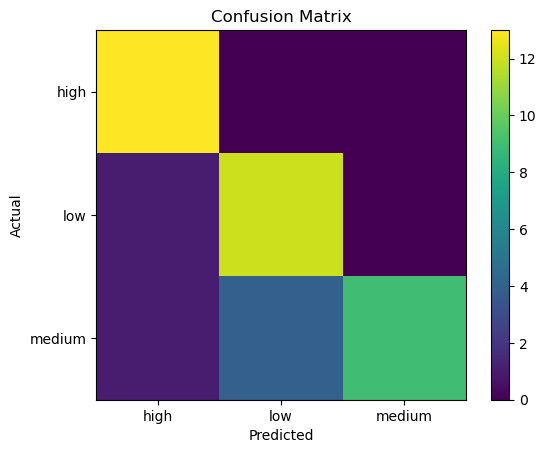

In [119]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()

import matplotlib.pyplot as plt
import numpy as np

labels = le.classes_

plt.figure()
plt.imshow(cm)

plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()
plt.show()